# 3D magnetics spatial fit — DIII-D (configurable shot)

A worked example of the **SLCONTOUR-style quasi-stationary spatial fit** (VISION.md §4.1),
run **locally** — off OMFIT and off MDSplus — using the ported OMFIT magnetics scripts in this
directory.  It reads the per-shot signals from `data/datafile/shot_<shot>.h5` and the device
geometry from `data/device/diiid.json`.

**Pipeline:** `load → prep → fit → plot`, the local translation of the OMFIT
`fetch → prep → fit → plot` workflow:

| local module | OMFIT script |
|---|---|
| `io_data.load_shot` | `SCRIPTS/fetch_magnetics.py` + `init_magnetics.py` (signals + derived geometry) |
| `prep.prepare` | `SCRIPTS/prep_magnetics.py` |
| `fit.fit` | `SCRIPTS/fit_magnetics.py` |
| `run.run_steps` | `SCRIPTS/run_magnetics.py` |
| `plots.*` | `PLOTS/plot_magnetics_*.py` |

The run is driven entirely by the **Parameters** cell below — change `SHOT`, `CHANNEL_FILTER`,
`TIME_TRIM`, or the mode lists to analyse a different shot or array.  The default analyses the
LFS-midplane toroidal Bp array (`Bp_LFS_midplane`) of shot **199749** for toroidal mode numbers
n = 1, 2, 3.

In [1]:
import sys
sys.path.insert(0, '.')  # make the local modules importable

import numpy as np
import matplotlib.pyplot as plt

from io_data import load_shot, valid_channels, available_subsets
from omfit_compat import resolve_channel_filter
from run import run_steps
import plots

%matplotlib inline

## Run parameters

Everything below is driven by these names — this is the only cell to edit to analyse a different
shot or sensor array.

In [2]:
# ── Run parameters — change these to analyse a different shot/array ──
SHOT           = 199749                 # data/datafile/shot_<SHOT>.h5
CHANNEL_FILTER = 'Bp_LFS_midplane'      # friendly name (see available_subsets) or a regex
TIME_TRIM      = (3.3, 3.5)             # seconds; must lie inside the shot file's window
NS, MS         = (1, 2, 3), (0,)        # toroidal / poloidal mode numbers

# detrend: 'none' | 'baseline' | 'linear' | 'endpoints'.  DETREND_BAND is the
# sub-window used to estimate the trend — here the first 0.01 s of TIME_TRIM.
DETREND_TYPE   = 'baseline'
DETREND_BAND   = (TIME_TRIM[0], TIME_TRIM[0] + 0.01)

PREP_KWARGS    = dict(cutoff_hz=(5, 250), energy=0.98,
                      detrend_type=DETREND_TYPE, detrend_band=DETREND_BAND)

## 1. Load the shot (the "fetch" + "init" step)

`load_shot` reads the raw sensor signals from `data/datafile/shot_<SHOT>.h5` and joins the
per-channel geometry — including the derived sensor-end coordinates (`*_end1/2`) — from
`data/device/diiid.json`.  All sensor channels are interpolated onto a single common time axis
(in seconds); the global `ip`/`bt` traces become the `plasma` Dataset.  The new files carry no
DC-coupling matrix, so `coupling` is `None`.

In [3]:
sd = load_shot(SHOT)
print(f'shot {sd.shot}  device {sd.device}')
print('RAW channels:', sd.raw.sizes['channel'], ' time samples:', sd.raw.sizes['time'])
print(f'file window: {float(sd.raw.time[0]):.4f}–{float(sd.raw.time[-1]):.4f} s')
print('helicity:', sd.plasma.attrs['helicity'])

# channels in the selected array that carry good data
good = valid_channels(sd.raw, CHANNEL_FILTER, sd.device)
print(f'\n{CHANNEL_FILTER}: {len(good)} valid sensors  -> resolves |n| <= {(len(good)-1)//2}')
print(good)

# the plot helpers match channel names with re.match, so turn the friendly
# filter into an explicit regex of its sensor names
ARRAY_REGEX = '|'.join(resolve_channel_filter(CHANNEL_FILTER, sd.device))

shot 199749  device DIII-D
RAW channels: 155  time samples: 39993
file window: 3.3000–3.5000 s
helicity: -1

Bp_LFS_midplane: 9 valid sensors  -> resolves |n| <= 4
[np.str_('MPID66M067'), np.str_('MPID66M097'), np.str_('MPID66M127'), np.str_('MPID66M157'), np.str_('MPID66M200'), np.str_('MPID66M247'), np.str_('MPID66M277'), np.str_('MPID66M307'), np.str_('MPID66M340')]


### Named sensor / coil subsets

Any of these names can be passed as `CHANNEL_FILTER` (they come from the `sensor_sets` in
`data/device/diiid.json`; names work with spaces or underscores).

In [4]:
for name, sensors in available_subsets(sd.device).items():
    print(f'{name:24s} {sensors}')

Bp LFS midplane          ['MPID66M020', 'MPID66M067', 'MPID66M097', 'MPID66M127', 'MPID66M157', 'MPID66M200', 'MPID66M247', 'MPID66M277', 'MPID66M307', 'MPID66M340']
Bp LFS midplane bdot     ['MPI66M020D', 'MPI66M067D', 'MPI66M097D', 'MPI66M127D', 'MPI66M132D', 'MPI66M137D', 'MPI66M157D', 'MPI66M200D', 'MPI66M247D', 'MPI66M277D', 'MPI66M307D', 'MPI66M312D', 'MPI66M322D', 'MPI66M340D']
Bp LFS R+1               ['MPID67A022', 'MPID67A037', 'MPID67A052', 'MPID67A097', 'MPID67A157', 'MPID67A217', 'MPID67A277', 'MPID67A337']
Bp LFS R+2               ['MPID79A072', 'MPID79A147', 'MPID79A222', 'MPID79A272']
Bp LFS R-1               ['MPID67B022', 'MPID67B037', 'MPID67B052', 'MPID67B097', 'MPID67B157', 'MPID67B217', 'MPID67B277', 'MPID67B337']
Bp LFS R-2               ['MPID79B067', 'MPID79B142', 'MPID79B217', 'MPID79B277']
Bp LFS Sensors           ['MPID66M020', 'MPID66M067', 'MPID66M097', 'MPID66M127', 'MPID66M157', 'MPID66M200', 'MPID66M247', 'MPID66M277', 'MPID66M307', 'MPID66M340', 'MPID6

## 2. Sensor geometry

The toroidal array sits at the LFS midplane (`theta ≈ 0`), spread around the torus in `phi`.

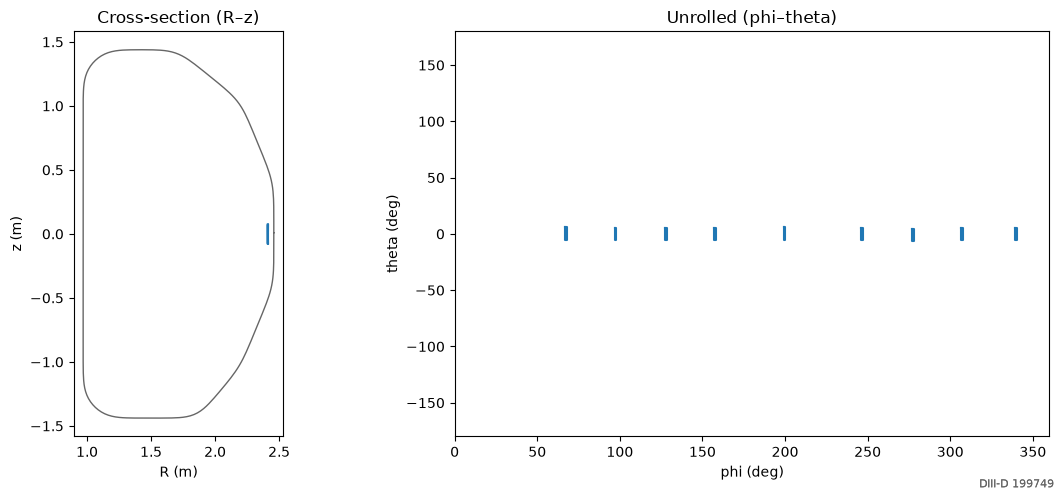

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
plots.plot_sensors(sd.raw, ARRAY_REGEX, geometry='rz', ax=ax[0])
ax[0].set_title('Cross-section (R–z)')
plots.plot_sensors(sd.raw, ARRAY_REGEX, geometry='cylindrical', ax=ax[1])
ax[1].set_title('Unrolled (phi–theta)')
plt.tight_layout()

### Where the named sensor sets sit

Overlay several named Bp sensor sets from `diiid.json`, each set in its own colour. The unrolled
(phi, theta) panel shows the arrays as bands at distinct poloidal angles (midplane, R±1, R±2,
HFS); the R–z panel shows their radial placement against the wall. (Sets whose sensors aren't in
this shot simply don't draw.)

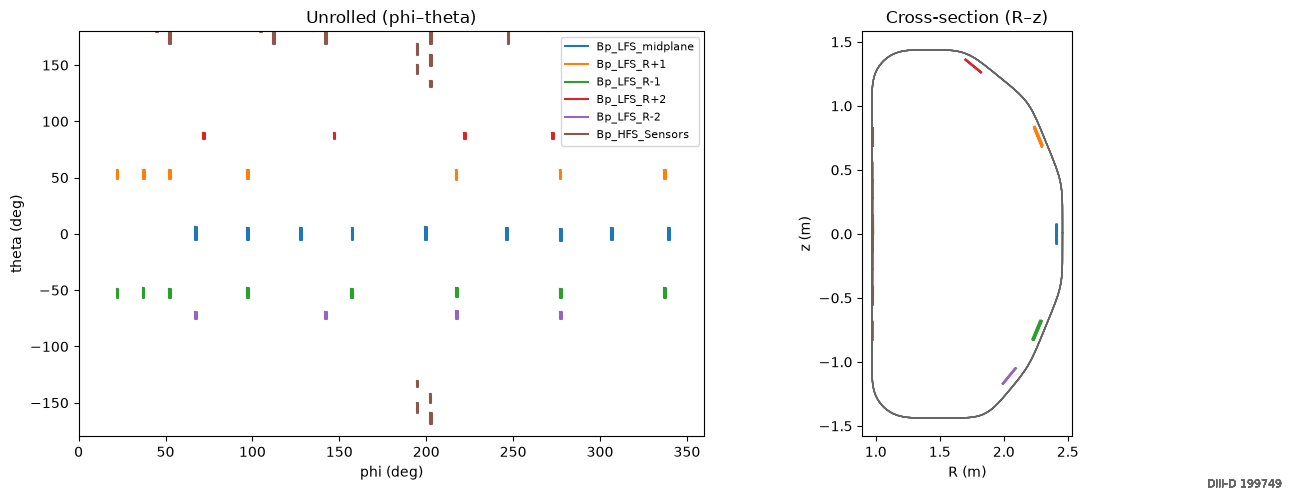

In [6]:
sets = ['Bp_LFS_midplane', 'Bp_LFS_R+1', 'Bp_LFS_R-1', 'Bp_LFS_R+2', 'Bp_LFS_R-2', 'Bp_HFS_Sensors']
colors = plt.cm.tab10.colors

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
handles = []
for i, name in enumerate(sets):
    regex = '|'.join(resolve_channel_filter(name, sd.device))  # friendly name -> regex of its sensors
    plots.plot_sensors(sd.raw, regex, geometry='cylindrical', ax=ax[0], color=colors[i])
    plots.plot_sensors(sd.raw, regex, geometry='rz',          ax=ax[1], color=colors[i])
    handles.append(plt.Line2D([], [], color=colors[i], label=name))

ax[0].set_title('Unrolled (phi–theta)')
ax[1].set_title('Cross-section (R–z)')
ax[0].legend(handles=handles, fontsize=8, loc='upper right')
plt.tight_layout()

## 3. Prep + fit

`run_steps` trims to the `TIME_TRIM` window (3.3–3.5 s for shot 199749), causal band-passes
5–250 Hz, SVD-conditions the data matrix (keeping 98% of the energy), removes a `DETREND_TYPE`
baseline estimated from the first 0.01 s of the window, and fits the n = 1, 2, 3 toroidal
harmonics. The reported **condition number K** is the central trust metric (warn K > 10, error
K > 20).

In [7]:
r = run_steps(
    SHOT,
    channel_filter=CHANNEL_FILTER,
    ns=NS, ms=MS,
    time_trim=TIME_TRIM,
    prep_kwargs=PREP_KWARGS,
)
print(f'\ncondition number K = {r.condition_number:.2f}')
print(f'mean reduced chi^2 = {float(np.nanmean(r.fit["red_chi_sq"].values)):.1f}')
print(f'data-matrix SVD effective rank (98% energy) = {r.fit.attrs["signal_effective_rank"]} '
      f'of {r.fit.sizes["channel"]} sensors')

 - Trimming channels and time
 - Downsampling x134
 - Filtering
   > causal bandpass
 - Removing baseline
 - Conditioning data matrix
   > SVD found 7 coherent structures of interest
Fitting the prepared data
 - Fitting signal
 - Raw / effective condition number = 2.02 / 2.02
 - Mean reduced chi squared = 5.728e+00

condition number K = 2.02
mean reduced chi^2 = 5.7
data-matrix SVD effective rank (98% energy) = 7 of 9 sensors


## 4. Signal conditioning

PREPARED traces (band-passed, SVD-cleaned) over the faint shifted RAW traces.

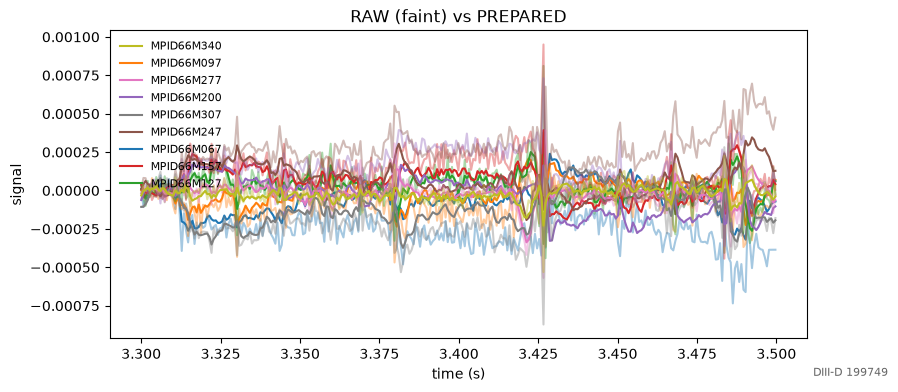

In [8]:
plots.plot_signal(r.raw, r.prepared, ARRAY_REGEX)
plt.gcf().set_size_inches(9, 4)

## 5. SVD conditioning (VISION's ≈ 98% energy)

**Top:** cumulative energy of the data-matrix singular values — a handful of coherent spatial
structures capture nearly all the energy (the rotating mode + its harmonics), the rest is noise.
**Bottom:** the design-matrix condition number per singular value, against the `fit_cond` cutoff.

array([<Axes: title={'center': 'Data Matrix Conditioning'}, xlabel='Cumulative Singular Value Index', ylabel='Energy Fraction'>,
       <Axes: title={'center': 'Design Matrix Conditioning'}, xlabel='Singular Value Index', ylabel='Condition Number'>],
      dtype=object)

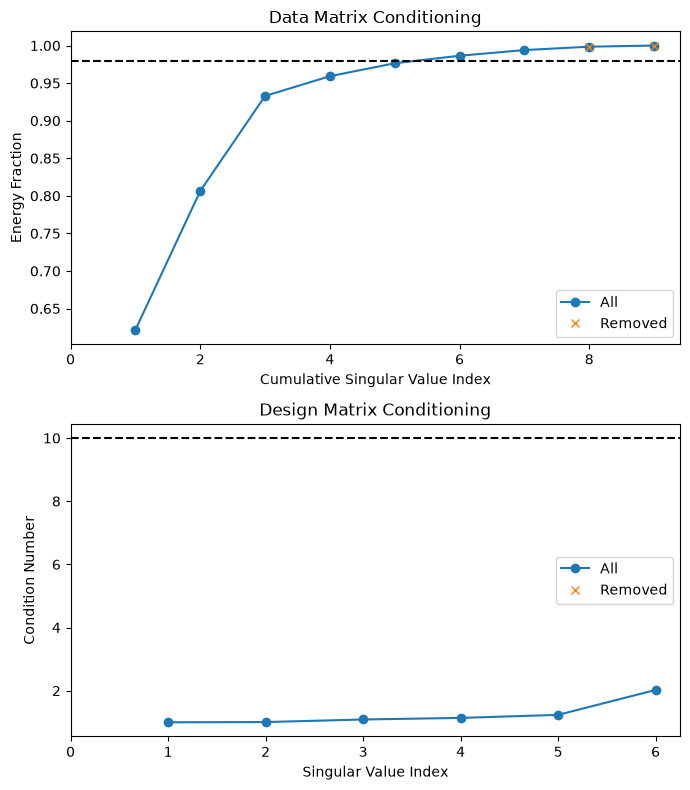

In [9]:
plots.plot_svds(r.fit)

## 6. Fit quality

Reduced chi^2, the signals, and the worst residuals. (chi^2 sits above 1 here because the
constant 2e-5 T sensor sigma is optimistic relative to unmodeled higher-n structure — the residuals
are still small compared with the signals.)

array([<Axes: title={'center': '199749'}, xlabel='time', ylabel='Reduced $\\chi^2$'>,
       <Axes: xlabel='time', ylabel='Signal'>,
       <Axes: xlabel='time (s)', ylabel='Residual'>], dtype=object)

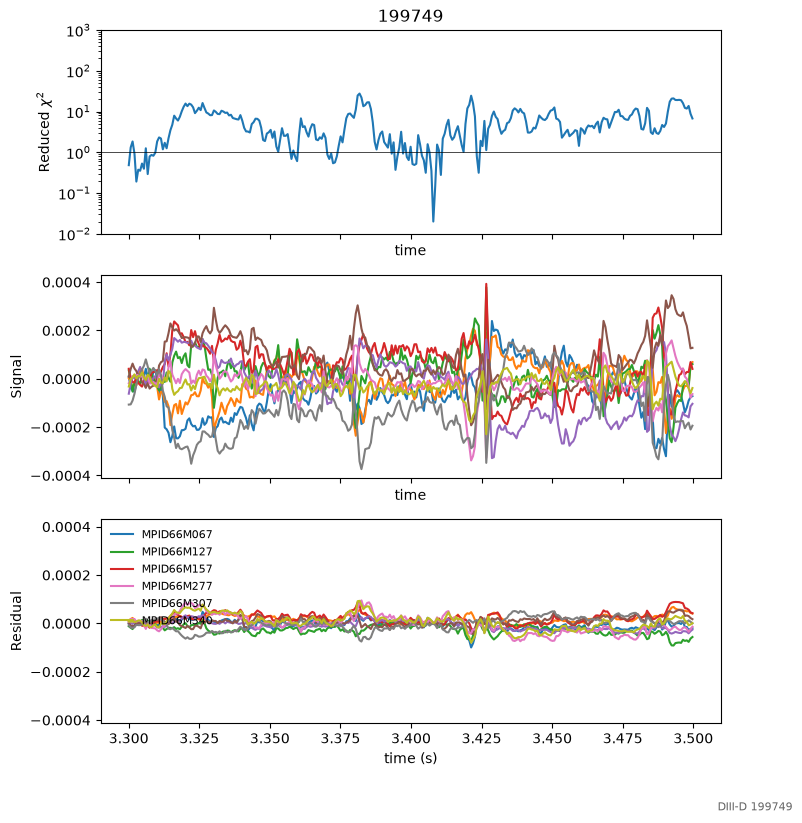

In [10]:
plots.plot_fit(r.fit)

## 7. Mode amplitude & phase vs time

Amplitude and phase of each fitted (n, m) mode through the window. A **rotating** mode shows a
phase that winds steadily in time; as a mode **slows and locks** its phase flattens and its
amplitude typically grows. (For VISION's reference shot 154551 the n = 1 does exactly this —
rotating early, then slowing and locking.)

array([<Axes: title={'center': '199749'}, ylabel='Amplitude'>,
       <Axes: xlabel='Time (s)', ylabel='Phase (deg)'>], dtype=object)

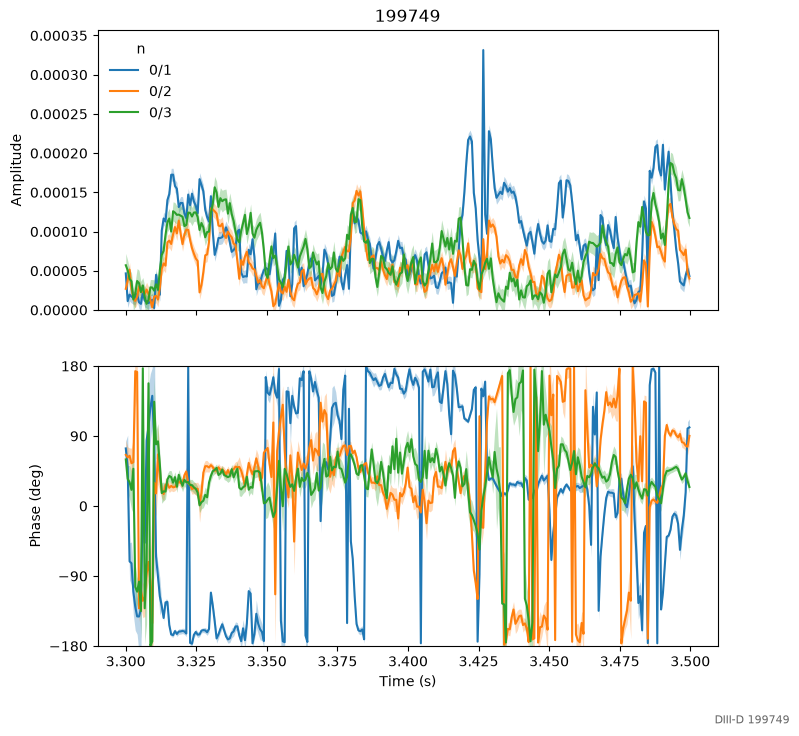

In [11]:
plots.plot_fit_modes(r.fit)

## 8. The SLCONTOUR phi-vs-time contour

Reconstruct the fitted dB on a (toroidal angle) × time grid. A rotating mode shows **diagonal
stripes**; a mode that slows and locks straightens those stripes into vertical bands. White
markers trace the instantaneous peak (the mode's toroidal phase); the top panel is the RMS
amplitude.

<Axes: xlabel='Time (s)', ylabel='Toroidal Angle (deg.)'>

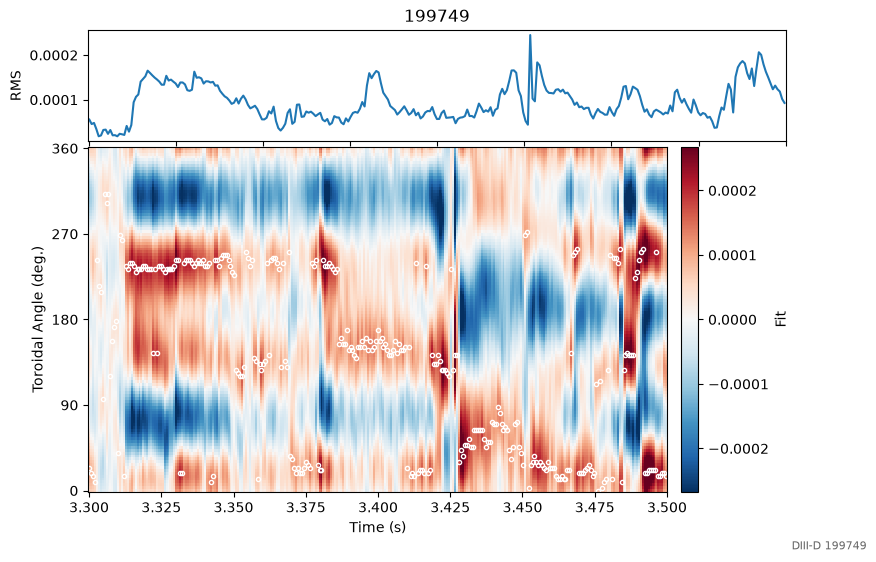

In [12]:
# fix_value is the poloidal angle of the slice; the LFS-midplane array sits at theta ~ 0
plots.plot_slice(r.fit, fix_coord='theta', fix_value=0.0)

---
### Recap

We reproduced the VISION §4.1 SLCONTOUR outputs locally from the ported OMFIT scripts, driven
off the `data/datafile/shot_<SHOT>.h5` signals and `data/device/diiid.json` geometry: sensor map,
conditioned signals, data/design-matrix SVD diagnostics, fit quality, **amplitude & phase of each
(n, m) mode vs time**, and the **phi-vs-time contour**. To analyse a different shot or array, edit
the **Parameters** cell (`SHOT`, `CHANNEL_FILTER`, `TIME_TRIM`, `NS`/`MS`).